In [1]:
import numpy as np
import scipy as scipy
import scipy.special
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import colors
import time
import uncertainties as error
import pandas as pd
np.random.seed(12345) #pi seed for pi finding

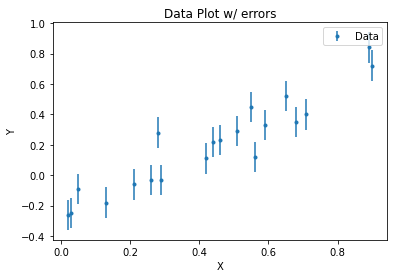

In [24]:
#This is my data input for the .txt files, may need to adjust the filepath
Data=pd.read_csv('HW6_Data/model_selection.txt', names=['x', 'y', 'yerr'], delim_whitespace=True)

plt.errorbar(Data['x'], Data['y'], yerr=Data['yerr'], label='Data', linestyle='', fmt='.')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

Problem 1.)

22857.507994491156
[ 1.10204082 -0.28571429]


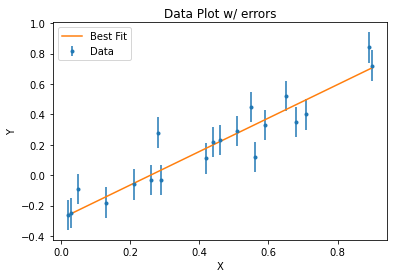

In [55]:
#Part A is calculating p(D|M_1) where M_1=y=mx+b and p(D|M_1) = integral over theta of p(D|theta)p(theta|M)dtheta
#And theta we can assume are uniform from -2 to 2 for both slope and yint
#Assume data errorvalues are Gaussian

#I need my parameters, which will just be a flattened 2D grid
density = 50
mlist = np.linspace(-2, 2, density)
blist = np.linspace(-2, 2, density)
M, B = np.meshgrid(mlist, blist) #makes the 2D grid
theta = np.column_stack((M.ravel(), B.ravel())) #flattens it out. Theta is now a list of [slope, yint]

#OK now we have our prior, we need to have a likelyhood function 
#Copying some code from HW4 and HW5
def logPDataGivenParam(Data, theta):
    temp=[]
    for i in range(len(Data['y'])):
        temp.append(-0.5 * (((Data['y'][i] - (theta[0]*Data['x'][i]+theta[1]))/Data['yerr'][i])**2 
                            + np.log(2*np.pi*Data['yerr'][i]**2)))
    logLikelyhood = np.sum(temp) 
    return(logLikelyhood)

#now we need to cover p(theta|M)
#Since we have uniform priors between -2 and 2 I think this is just a constant
#Should be like 1/(4)(4) where each 4 is the range of prior (-2 to 2)
Prior=1/16
da = (mlist[1] - mlist[0]) #gets spacing for integral
db = (blist[1] - blist[0])

#now we actually do the integral
#Except we can convert this to a sum since we have discrete points
temp_2parameters = 0
LikelyhoodValues = []
for theta_i in theta:
    Likelyhood = np.exp(logPDataGivenParam(Data, theta_i))
    temp_2parameters += Likelyhood * Prior * da * db
    LikelyhoodValues.append(Likelyhood)
print(temp_2parameters)
thetabest = theta[np.argmax(LikelyhoodValues)]
print(theta[np.argmax(LikelyhoodValues)])
#This is pretty reasonable values for theta looking at the data

plt.errorbar(Data['x'], Data['y'], yerr=Data['yerr'], label='Data', linestyle='', fmt='.')
plt.plot(Data['x'], Data['x']*thetabest[0] + thetabest[1], label='Best Fit')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

7454.627464432162
[ 0.7755102  -0.20408163  0.28571429]


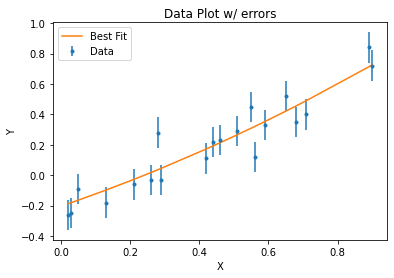

In [56]:
#Part B here we use a quadratic model with a new parameter in theta for cx^2
density = 50
mlist = np.linspace(-2, 2, density)
blist = np.linspace(-2, 2, density)
clist = np.linspace(-2, 2, density)
M, B, C = np.meshgrid(mlist, blist, clist) #makes the 2D grid
theta = np.column_stack((M.ravel(), B.ravel(), C.ravel())) #flattens it out. Theta is now a list of [slope, yint]

def logPDataGivenParam(Data, theta):
    temp=[]
    for i in range(len(Data['y'])):
        temp.append(-0.5 * (((Data['y'][i] - (theta[0]*Data['x'][i]+theta[1]+theta[2]*Data['x'][i]**2))/Data['yerr'][i])**2 
                            + np.log(2*np.pi*Data['yerr'][i]**2)))
    logLikelyhood = np.sum(temp) 
    return(logLikelyhood)

Prior=1/(4**3)
da = (mlist[1] - mlist[0]) #gets spacing for integral
db = (blist[1] - blist[0])
dc = (clist[1] - clist[0])

temp_3parameters = 0
LikelyhoodValues = []
for theta_i in theta:
    Likelyhood = np.exp(logPDataGivenParam(Data, theta_i))
    temp_3parameters += Likelyhood * Prior * da * db * dc
    LikelyhoodValues.append(Likelyhood)
print(temp_3parameters)
thetabest = theta[np.argmax(LikelyhoodValues)]
print(theta[np.argmax(LikelyhoodValues)])

plt.errorbar(Data['x'], Data['y'], yerr=Data['yerr'], label='Data', linestyle='', fmt='.')
plt.plot(Data['x'], Data['x']*thetabest[0] + thetabest[1] + Data['x']**2 * thetabest[2], label='Best Fit')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

In [57]:
#now for B_ij
#B_ij = p(M_i|D)/p(M_j|D) * p(M_j)/p(M_i)
#Since the priors are uniform, we can ignore that part. No prior saying we should take one model over the other more

#B_ij = p(M_i|D)/p(M_j|D)
print('B_ij:', temp_2parameters/temp_3parameters)
#This is the Bayes factor for linear/quadratic. So we are in favor of a linear model being the better model
#I don't think it's the strongest support for, but the Bayes factor shows that the slight improvement in fit
#given by the quadratic model is not worth the added complexity from the quadratic model

B_ij: 3.066217339974382
